In [1]:
# %% [setup]
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect_langs
import fasttext

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ── load data ──────────────────────────────────────────────────────────────────
DATA_PATH = Path.cwd().parent.parent / "data" / "processed" / "dataset_filled_subjects_new.csv"

nodes = pd.read_csv(DATA_PATH, usecols=["thesis", "year", "subject_code", "subject_name"])
nodes["year"] = pd.to_numeric(nodes["year"], errors="coerce")
nodes["subject_code"] = pd.to_numeric(nodes["subject_code"], errors="coerce").astype("Int64")
df = nodes.dropna(subset=["thesis", "year", "subject_code"]).copy()
df["year"] = df["year"].astype(int)
df["code"] = df["subject_code"].astype(int).astype(str).str.zfill(2)

print(f"Working set: {len(df):,} rows")

Working set: 234,743 rows


In [ ]:
# %% [data completeness -- column coverage]
cols_of_interest = ["thesis", "year", "subject_code", "subject_name"]

# --- per-column non-null counts ---
coverage = pd.DataFrame({
    "non_null": [nodes[c].notna().sum() for c in cols_of_interest],
    "null":     [nodes[c].isna().sum()  for c in cols_of_interest],
    "total":    len(nodes),
}, index=cols_of_interest)
coverage["fill_%"] = (coverage["non_null"] / coverage["total"]).map("{:.1%}".format)

print("=== Per-column coverage ===")
print(coverage.to_string())
print()

# --- combination counts (thesis is always required) ---
combos = {
    "thesis only":                    nodes["thesis"].notna(),
    "thesis + year":                  nodes["thesis"].notna() & nodes["year"].notna(),
    "thesis + subject_code":          nodes["thesis"].notna() & nodes["subject_code"].notna(),
    "thesis + subject_name":          nodes["thesis"].notna() & nodes["subject_name"].notna(),
    "thesis + year + subject_code":   nodes["thesis"].notna() & nodes["year"].notna() & nodes["subject_code"].notna(),
    "thesis + year + subject_name":   nodes["thesis"].notna() & nodes["year"].notna() & nodes["subject_name"].notna(),
    "all four columns":               nodes[cols_of_interest].notna().all(axis=1),
}

combo_df = pd.DataFrame({
    "count": {k: v.sum() for k, v in combos.items()},
    "pct":   {k: f"{v.mean():.1%}" for k, v in combos.items()},
})

print("=== Combination coverage ===")
print(combo_df.to_string())

=== Per-column coverage ===
              non_null   null   total fill_%
thesis          307399  31133  338532  90.8%
year            277237  61295  338532  81.9%
subject_code    302106  36426  338532  89.2%
subject_name    302106  36426  338532  89.2%

=== Combination coverage ===
                               count    pct
thesis only                   307399  90.8%
thesis + year                 262264  77.5%
thesis + subject_code         275319  81.3%
thesis + subject_name         275319  81.3%
thesis + year + subject_code  234743  69.3%
thesis + year + subject_name  234743  69.3%
all four columns              234743  69.3%


In [4]:
# %% [fasttext predictions]
ft_model = fasttext.load_model("lid.176.bin")

titles = (
    df["thesis"].astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
    .tolist()
)

labels, probs = ft_model.predict(titles)

df["lang_ft"]    = [lab[0].replace("__label__", "") if lab else "unknown" for lab in labels]
df["prob_ft"]    = [float(p[0]) if p else 0.0 for p in probs]
df["is_en_ft"]   = df["lang_ft"] == "en"

print(f"[fasttext]  English: {df['is_en_ft'].sum():,}  ({df['is_en_ft'].mean():.1%})")

[fasttext]  English: 208,150  (88.7%)


In [7]:
# %% [langdetect predictions]
from langdetect import detect_langs, DetectorFactory
from joblib import Parallel, delayed

# langdetect is non-deterministic by default -- fix the seed for reproducibility
DetectorFactory.seed = 0

MIN_PROB = 0.90

def ld_predict(text):
    """Returns ('en', prob) or (best_lang, prob). Never raises."""
    text = str(text).strip()
    if not text:
        return "unknown", 0.0
    try:
        results = detect_langs(text)
        for r in results:
            if r.lang == "en":
                return "en", r.prob
        return results[0].lang, results[0].prob
    except Exception:
        return "unknown", 0.0

# n_jobs=-1 uses all cores; prefer="threads" avoids pickling overhead
# langdetect releases the GIL during detection so threads are effective here
ld_results = Parallel(n_jobs=-1, prefer="threads", verbose=1)(
    delayed(ld_predict)(t) for t in titles
)

df["lang_ld"]  = [r[0] for r in ld_results]
df["prob_ld"]  = [r[1] for r in ld_results]
df["is_en_ld"] = (df["lang_ld"] == "en") & (df["prob_ld"] >= MIN_PROB)

print(f"[langdetect] English: {df['is_en_ld'].sum():,}  ({df['is_en_ld'].mean():.1%})")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 402 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 752 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 1202 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 1752 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 2402 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 3152 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 4002 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 4952 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 6002 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 7152 tasks      | elapsed:   11.0s
[Parallel(n_jobs=-1)]: Done 8402 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 9752 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 11202 tasks 

[langdetect] English: 191,771  (81.7%)


[Parallel(n_jobs=-1)]: Done 234743 out of 234743 | elapsed: 10.6min finished


In [8]:
# %% [agreement summary]
df["agree"]    = df["is_en_ft"] == df["is_en_ld"]
df["verdict"]  = "agree"
df.loc[ df["is_en_ft"] & ~df["is_en_ld"], "verdict"] = "ft_only"   # fasttext says EN, langdetect says NO
df.loc[~df["is_en_ft"] &  df["is_en_ld"], "verdict"] = "ld_only"   # langdetect says EN, fasttext says NO

counts = df["verdict"].value_counts()
print(counts.to_string())
print(f"\nDisagreement rate: {(~df['agree']).mean():.2%}")

verdict
agree      217512
ft_only     16805
ld_only       426

Disagreement rate: 7.34%


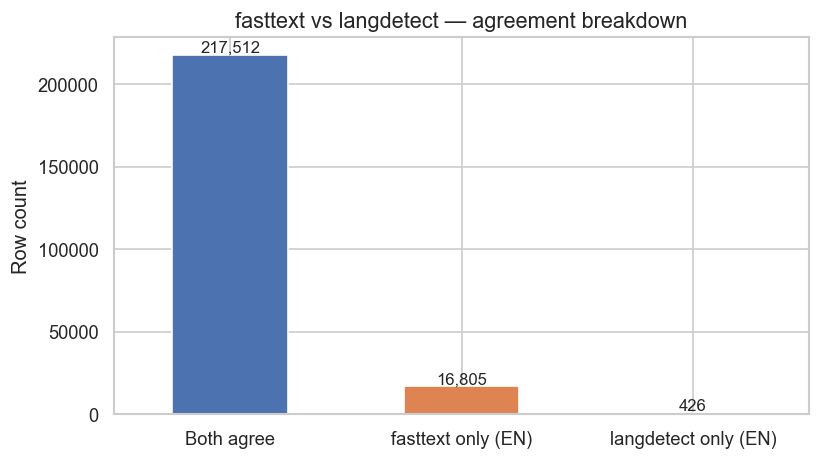

In [9]:
# %% [figure 1 -- agreement breakdown bar]
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"agree": "#4C72B0", "ft_only": "#DD8452", "ld_only": "#55A868"}
counts.plot.bar(ax=ax, color=[colors[k] for k in counts.index], edgecolor="white")

ax.set_title("fasttext vs langdetect — agreement breakdown", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Row count")
ax.set_xticklabels(
    ["Both agree", "fasttext only (EN)", "langdetect only (EN)"],
    rotation=0
)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("fig_agreement_bar.png")
plt.show()

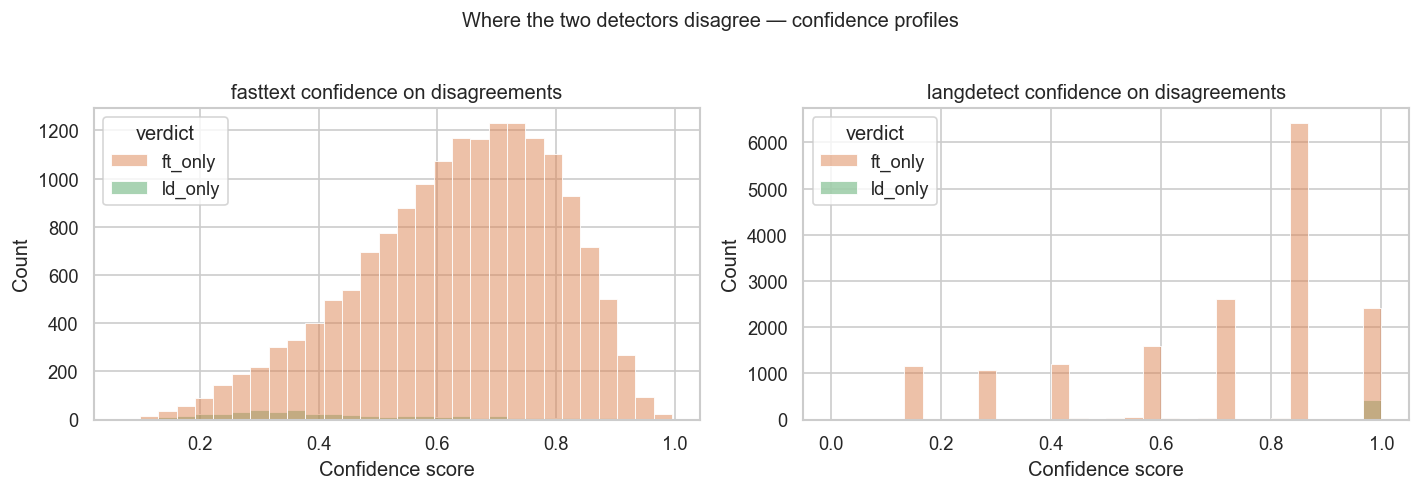

In [10]:
# %% [figure 2 -- confidence distributions on disagreements]
dis = df[~df["agree"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, col, label, color in zip(
    axes,
    ["prob_ft", "prob_ld"],
    ["fasttext confidence", "langdetect confidence"],
    ["#DD8452", "#55A868"],
):
    sns.histplot(
        data=dis, x=col, hue="verdict",
        bins=30, ax=ax, palette={"ft_only": "#DD8452", "ld_only": "#55A868"},
        edgecolor="white", linewidth=0.5
    )
    ax.set_title(f"{label} on disagreements")
    ax.set_xlabel("Confidence score")

plt.suptitle("Where the two detectors disagree — confidence profiles", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("fig_confidence_disagreements.png")
plt.show()

In [12]:
# %% [spot-check -- disputed titles]
print("=== fasttext says EN, langdetect disagrees ===")
sample_ft = (
    df[df["verdict"] == "ft_only"]
    [["thesis", "prob_ft", "lang_ld", "prob_ld"]]
    .sample(15, random_state=42)
)
display(sample_ft)

print("\n=== langdetect says EN, fasttext disagrees ===")
sample_ld = (
    df[df["verdict"] == "ld_only"]
    [["thesis", "lang_ft", "prob_ft", "prob_ld"]]
    .sample(15, random_state=42)
)
display(sample_ld)

=== fasttext says EN, langdetect disagrees ===


,thesis,prob_ft,lang_ld,prob_ld
67078,Single Machine Changeover Scheduling,0.665549,de,0.999995
101710,A Modified Version of Teorell's Biological Cel...,0.638783,en,0.714284
193896,A Materialist Dialectica,0.244519,ro,0.999993
153034,Analyzing Probabilistic Graphs,0.467000,en,0.142861
212301,Codes in distance-regular graphs,0.795272,en,0.429504
18857,On Hilbert Schemes,0.368897,de,0.999996
235243,Iwasawa algebras for p-adic Lie groups and Gal...,0.772578,en,0.857140
265095,"Three Philosophers: Kierkegaard, Nietzsche and...",0.634392,de,0.999996
188895,Iterative deformable finite element model for ...,0.642510,en,0.857140
30257,Omega-Cohesive Sets,0.396495,en,0.285714



=== langdetect says EN, fasttext disagrees ===


,thesis,lang_ft,prob_ft,prob_ld
333176,技术创新投资决策的期权博弈方法研究（Study on Technological Innov...,zh,0.558948,0.999997
63172,Inductorless Filters,es,0.369566,0.999995
147874,OpenDHT: A Public DHT Service,fr,0.469569,0.999995
15753,"On K (sub*)(B.G.) for G, a Finite Abelian Group",ceb,0.361262,0.999996
326680,Moderne therapie van thrombopenische purpura b...,nl,0.369909,0.999995
320302,Over explosieve gasreacties,nl,0.782552,0.999995
128693,Metody wariacyjne w teorii generatora synchron...,pl,0.626577,0.999997
127497,﻿Czas lokalny samoprzecięć procesów gaussowski...,pl,0.701167,0.999996
332904,Stochastyczne modele struktury terminowej stop...,pl,0.622110,0.999996
129957,Categorical System Theory,pt,0.283997,0.999998


In [13]:
# %% [quantitative summary table]
summary = pd.DataFrame({
    "detector":        ["fasttext", "langdetect"],
    "english_count":   [df["is_en_ft"].sum(), df["is_en_ld"].sum()],
    "english_pct":     [df["is_en_ft"].mean(), df["is_en_ld"].mean()],
    "median_conf_EN":  [
        df.loc[df["is_en_ft"],  "prob_ft"].median(),
        df.loc[df["is_en_ld"],  "prob_ld"].median(),
    ],
    "median_conf_nonEN": [
        df.loc[~df["is_en_ft"], "prob_ft"].median(),
        df.loc[~df["is_en_ld"], "prob_ld"].median(),
    ],
}).set_index("detector")

summary["english_pct"] = summary["english_pct"].map("{:.1%}".format)
print(summary.to_string())

            english_count english_pct  median_conf_EN  median_conf_nonEN
detector                                                                
fasttext           208150       88.7%        0.754637           0.949374
langdetect         191771       81.7%        0.999996           0.999995


        LANGUAGE DETECTION SUMMARY
            English  Non-English   Total English % Non-English %
fasttext     208150        26593  234743     88.7%         11.3%
langdetect   191771        42972  234743     81.7%         18.3%


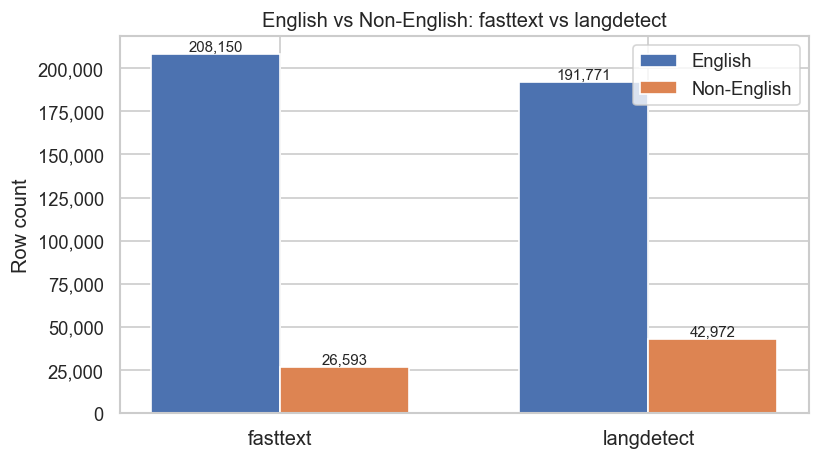

In [15]:
# %% [final summary -- English vs Non-English counts]
summary_counts = pd.DataFrame({
    "English":     [df["is_en_ft"].sum(),   df["is_en_ld"].sum()],
    "Non-English": [(~df["is_en_ft"]).sum(), (~df["is_en_ld"]).sum()],
    "Total":       [len(df), len(df)],
}, index=["fasttext", "langdetect"])

summary_counts["English %"]     = (summary_counts["English"] / summary_counts["Total"]).map("{:.1%}".format)
summary_counts["Non-English %"] = (summary_counts["Non-English"] / summary_counts["Total"]).map("{:.1%}".format)

print("=" * 55)
print("        LANGUAGE DETECTION SUMMARY")
print("=" * 55)
print(summary_counts.to_string())
print("=" * 55)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
width = 0.35

en_counts  = [df["is_en_ft"].sum(),    df["is_en_ld"].sum()]
non_counts = [(~df["is_en_ft"]).sum(), (~df["is_en_ld"]).sum()]

bars_en  = ax.bar(x - width/2, en_counts,  width, label="English",     color="#4C72B0", edgecolor="white")
bars_non = ax.bar(x + width/2, non_counts, width, label="Non-English", color="#DD8452", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(["fasttext", "langdetect"], fontsize=12)
ax.set_ylabel("Row count")
ax.set_title("English vs Non-English: fasttext vs langdetect", fontsize=12)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

for bar in list(bars_en) + list(bars_non):
    ax.annotate(
        f"{int(bar.get_height()):,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.savefig("fig_final_summary.png")
plt.show()

In [2]:
# %% [quick verify -- all thesis titles, both detectors]
import fasttext
from langdetect import detect_langs
from pathlib import Path
import pandas as pd

DATA_PATH = Path.cwd().parent.parent / "data" / "processed" / "dataset_filled_subjects_new.csv"

all_titles = (
    pd.read_csv(DATA_PATH, usecols=["thesis"])
    .dropna(subset=["thesis"])
    ["thesis"].astype(str).str.replace("\n", " ").str.strip()
)

print(f"Total titles: {len(all_titles):,}")

# --- fasttext ---
ft_model = fasttext.load_model("lid.176.bin")
labels, _ = ft_model.predict(all_titles.tolist())
is_en_ft = pd.Series([lab[0] == "__label__en" for lab in labels])

# --- langdetect ---
def is_english_ld(text, min_prob=0.90):
    try:
        return any(l.lang == "en" and l.prob >= min_prob for l in detect_langs(text))
    except:
        return False

is_en_ld = all_titles.apply(is_english_ld)

# --- results ---
total = len(all_titles)
print("\n                   English        Non-English")
print(f"fasttext     {is_en_ft.sum():>12,}    {(~is_en_ft).sum():>12,}   ({is_en_ft.mean():.1%} EN)")
print(f"langdetect   {is_en_ld.sum():>12,}    {(~is_en_ld).sum():>12,}   ({is_en_ld.mean():.1%} EN)")

Total titles: 307,399

                   English        Non-English
fasttext          252,522          54,877   (82.1% EN)
langdetect        232,332          75,067   (75.6% EN)


In [7]:
# 1. how many titles each detector exclusively claims
ft_only = is_en_ft & ~is_en_ld
ld_only = is_en_ld & ~is_en_ft
both_en = is_en_ft & is_en_ld
neither = ~is_en_ft & ~is_en_ld
print(f"Total titles: {len(all_titles):,}")
print("\n                   English        Non-English")
print(f"fasttext     {is_en_ft.sum():>12,}    {(~is_en_ft).sum():>12,}   ({is_en_ft.mean():.1%} EN)")
print(f"langdetect   {is_en_ld.sum():>12,}    {(~is_en_ld).sum():>12,}   ({is_en_ld.mean():.1%} EN)")
print("=== Agreement breakdown ===")
print(f"Both say English:       {both_en.sum():>8,}  ({both_en.mean():.1%})")
print(f"Both say Non-English:   {neither.sum():>8,}  ({neither.mean():.1%})")
print(f"fasttext only (EN):     {ft_only.sum():>8,}  ({ft_only.mean():.1%})")
print(f"langdetect only (EN):   {ld_only.sum():>8,}  ({ld_only.mean():.1%})")
print(f"Disagreement rate:      {(ft_only | ld_only).mean():.2%}")

# 2. title length breakdown -- short titles drive most disagreements
lengths = all_titles.str.split().str.len()
print("\n=== Median title length by group ===")
print(f"Both EN:              {lengths[both_en].median():.0f} words")
print(f"Both Non-English:     {lengths[neither].median():.0f} words")
print(f"fasttext only (EN):   {lengths[ft_only].median():.0f} words")
print(f"langdetect only (EN): {lengths[ld_only].median():.0f} words")

# %% [sample disputed titles -- index safe]

ft_only_titles = all_titles.reset_index(drop=True)[ft_only.reset_index(drop=True)]
ld_only_titles = all_titles.reset_index(drop=True)[ld_only.reset_index(drop=True)]

print("=== 10 titles fasttext says EN, langdetect says NO ===")
for t in ft_only_titles.sample(10, random_state=42).tolist():
    print(" ", t)

print("\n=== 10 titles langdetect says EN, fasttext says NO ===")
for t in ld_only_titles.sample(10, random_state=42).tolist():
    print(" ", t)

Total titles: 307,399

                   English        Non-English
fasttext          252,522          54,877   (82.1% EN)
langdetect        232,560          74,839   (75.7% EN)
=== Agreement breakdown ===
Both say English:        176,180  (52.5%)
Both say Non-English:     13,940  (4.2%)
fasttext only (EN):       52,881  (15.7%)
langdetect only (EN):     35,942  (10.7%)
Disagreement rate:      26.45%

=== Median title length by group ===
Both EN:              8 words
Both Non-English:     7 words
fasttext only (EN):   7 words
langdetect only (EN): 8 words
=== 10 titles fasttext says EN, langdetect says NO ===
  The optimal Berry-Esseen constant in the binomial case
  Automatic detection of change-points in nonparametric regression
  On Moves between Branched Coverings of the Three Sphere
  Contributions to the theory of generalized differential equations
  Time dilation : decreasing time to decision with discrete-event simulation
  Characterization of groups with a layer-finite period